# 主成分分析和逻辑回归

主成分分析所做的是无监督下的降维工作，而逻辑回归是预测的工作。

我们用GridSearchCV设置PCA的维数。


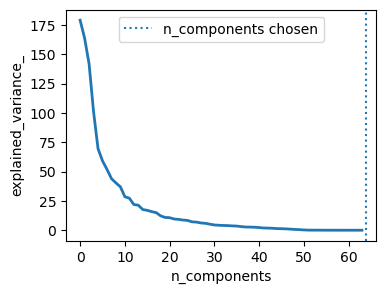

In [2]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, decomposition, datasets
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

logistic = linear_model.LogisticRegression(max_iter=1000)
pca    = decomposition.PCA()
scaler = StandardScaler()

pipe = Pipeline(steps=[('scaler', scaler),
                      ('pca', pca),
                      ('logistic', logistic)])

digits = datasets.load_digits()
X_digits, y_digits = digits.data, digits.target

# 画 PCA 方差解释比例
pca.fit(X_digits)
plt.figure(figsize=(4,3))
plt.plot(pca.explained_variance_, linewidth=2)
plt.xlabel('n_components')
plt.ylabel('explained_variance_')

# 网格搜索
param_grid = dict(pca__n_components=[20, 40, 64],
                  logistic__C=np.logspace(-4, 4, 3))
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_digits, y_digits)

plt.axvline(grid.best_estimator_.named_steps['pca'].n_components,
            linestyle=':', label='n_components chosen')
plt.legend()
plt.show()

(1797, 64)


<Figure size 640x480 with 0 Axes>

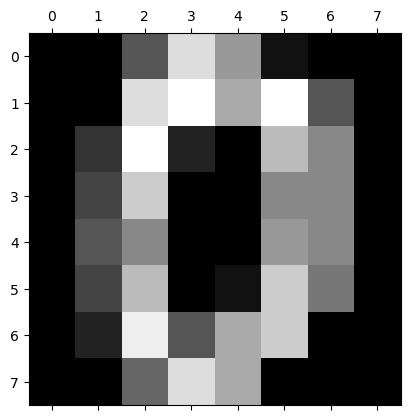

In [4]:
# Compare the performance
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn import decomposition
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# load digital data
digits, dig_label = load_digits(return_X_y=True)
print(digits.shape)

# draw one digital
plt.gray() 
plt.matshow(digits[0].reshape([8, 8])) 
plt.show() 


In [6]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 数据
digits = load_digits()
X, y = digits.data, digits.target          # 1797×64

# 划分
N = len(X)
N_train = int(N*0.8)
X_train, X_test = X[:N_train], X[N_train:]
y_train, y_test = y[:N_train], y[N_train:]

# 标准化 + 训练
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# 评估
acc_train = accuracy_score(y_train, lr.predict(X_train))
acc_test  = accuracy_score(y_test,  lr.predict(X_test))
print(f"accuracy train = {acc_train:.4f}, accuracy test = {acc_test:.4f}")

accuracy train = 1.0000, accuracy test = 0.8972


In [7]:
# do PCA with 'n_components=40'
pca = decomposition.PCA(n_components=40)
pca.fit(x_train)

x_train_pca = pca.transform(x_train)
x_test_pca = pca.transform(x_test)

# do logistic regression
lr=LogisticRegression()
lr.fit(x_train_pca,y_train)

pred_train = lr.predict(x_train_pca)
pred_test  = lr.predict(x_test_pca)

# calculate train/test accuracy
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)
print("accuracy train = %f, accuracy_test = %f" % (acc_train, acc_test))


accuracy train = 1.000000, accuracy_test = 0.894444


In [9]:
# do kernel PCA
#   Ref: http://scikit-learn.org/stable/auto_examples/decomposition/plot_kernel_pca.html

from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 标准化（KernelPCA 对尺度敏感）
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)

# 2. kernel PCA
# 计算 gamma = 1 / (n_features * X.var())
gamma_val = 1 / (x_train_s.shape[1] * x_train_s.var())
print('gamma =', gamma_val)

kpca = KernelPCA(n_components=45,
                 kernel='rbf',
                 gamma=gamma_val,
                 fit_inverse_transform=True)

x_train_kpca = kpca.fit_transform(x_train_s)
x_test_kpca  = kpca.transform(x_test_s)

# 3. 分类
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_kpca, y_train)

acc_tr = accuracy_score(y_train, lr.predict(x_train_kpca))
acc_te = accuracy_score(y_test,  lr.predict(x_test_kpca))
print(f'accuracy train = {acc_tr:.4f}, test = {acc_te:.4f}')


InvalidParameterError: The 'gamma' parameter of KernelPCA must be a float in the range [0.0, inf) or None. Got 'scale' instead.

## References
* [Pipelining: chaining a PCA and a logistic regression](http://scikit-learn.org/stable/auto_examples/plot_digits_pipe.html)
* [PCA进行无监督降维](https://ljalphabeta.gitbooks.io/python-/content/pca.html)